[*********************100%***********************]  1 of 1 completed


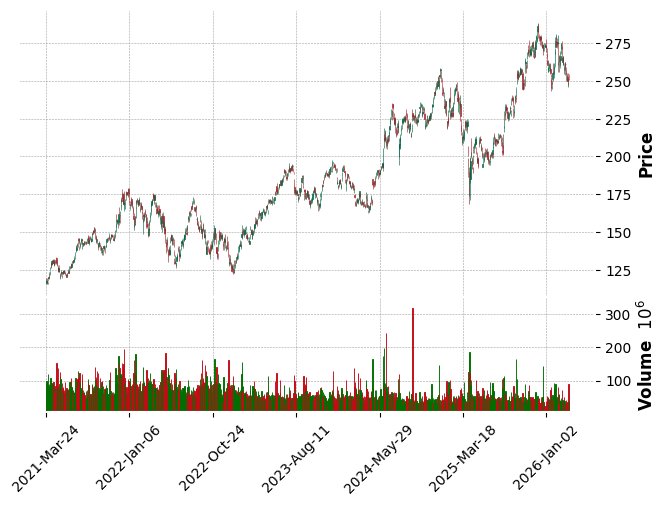

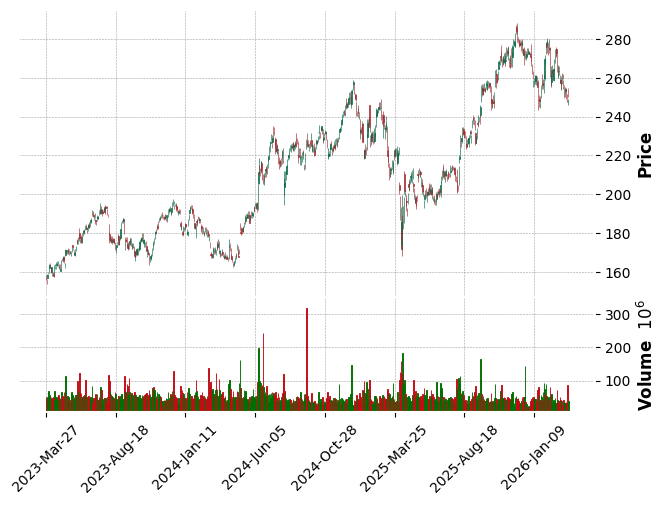

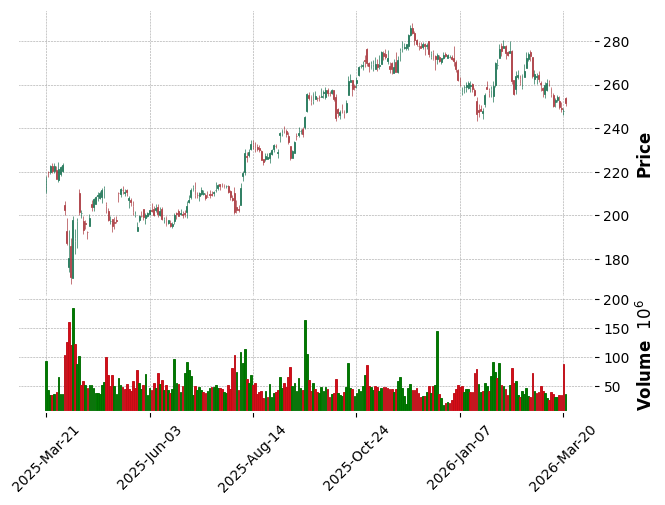

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


147.32333333333335


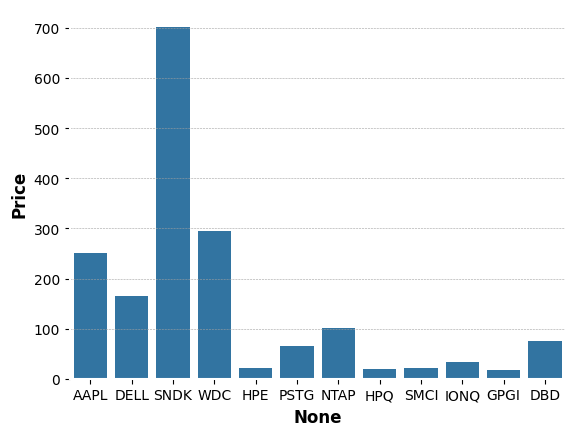

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bearish (Net Sell): -25,796 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-23 16:56:52
Melius analyst: Microsoft’s Copilot reorganization is a ‘red flag’
Microsoft (NASDAQ:MSFT) is down more than 20% year-to-date, making it the worst-performing stock in the Mag-7 by a wide margin. And according to Ben Wright of Melius Research, who recently cut his price target on the stock, the core problem has a name: Copilot. Wright’s red flag isn’t just about weak adoption numbers. It’s about ... Melius analyst: Microsoft’s Copilot reorganization is a ‘red flag’
https://finnhub.io/api/news?id=b4950aca003654e6a3494d8d26604e77d3a0191f8198ac29b1a0de294037b779

2026-03-23 15:45:02
Apple (AAPL) Beats Stock Market Upswing: What Investors Need to Know
Apple (AAPL) concluded the recent trading session at $251.49, signifying a +1.41% move from its prior day's close.
https://finnhub.io/api/news?id=fb4e2762aa5536c1462c40a2e82641568b7867be0902c7aeaa2a83a8d18cbb5d

2026-03-23 14:06:40
Apple Watch Ruling Keeps Key Revenue Stream Intact For Investors
Apple (NasdaqGS:AAPL) secure

Average Weighted EPS: 0.6601
Lower Standard Deviation: 0.06955596228218719
Upper Standard Deviation: 1.2506440377178127
Total Debt/Total Equity: 1.0263


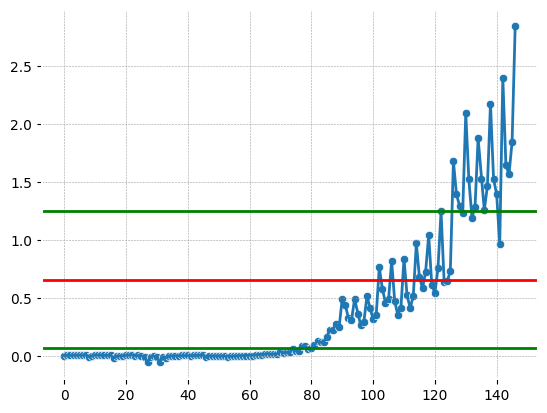

In [17]:
inflect = Fun.get_inflections()

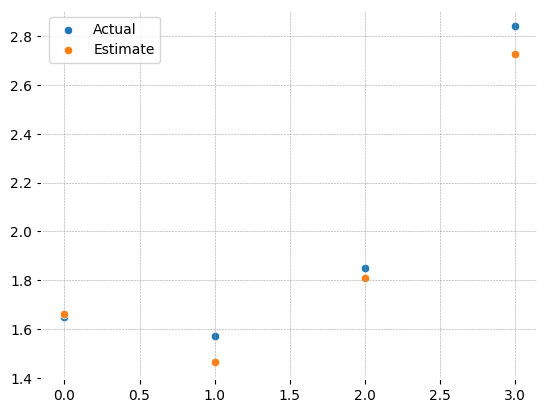

In [26]:
surprise = Fun.eps_surprise()

Revenue: [2.60174e+11 2.74515e+11 3.65817e+11 3.94328e+11 3.83285e+11 3.91035e+11
 4.16161e+11]


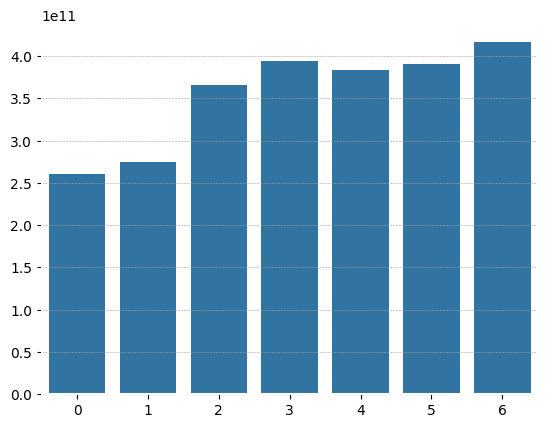

In [24]:
revenue = Fun.revenue_growth()